# Liquidity Predictor
Welcome to the eighth lesson! This Jupyter Notebook file is meant to accompany **L08 - Liquidity Predictor.**

Type your solutions for each exercise in the code cells below, and then press **Shift + Enter** to execute your code. Then, check the solution video to see how you did!

### 1. Liquidity Predictor Introduction

**Concepts:** This project predicts a continuous target (liquidity) from structured features. The overall workflow is: load data, explore it, split into train/test sets, train multiple models, tune hyperparameters, and evaluate performance.

In [1]:
import pandas as pd
df_client = pd.read_csv('../data/raw/liquidity_client.csv')

In [2]:
df_client.head(5)

,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
0,2,54856.1961,84628,-9262,21387.00032,9488,170315


### 2. Data Exploration

**Concepts:** Data exploration checks structure and quality before modeling. Use `.shape`, `.head()`, and `.describe()` to inspect dimensions, sample rows, and numeric distributions so issues are found early.

![Exercise 2.1](../figures/exercise_2_1.png)

<font color = 'blue'> **EXERCISE 2.1** </font>

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
df_liquidity = pd.read_csv('../data/raw/liquidity_data.csv')
df_liquidity.head(3)

,available_liquidity,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
0,28694.04271,2,54856.1961,84628.0,-9262.0,21387.00032,9488.0,170315.0
1,24784.00051,7,209150.6401,57909.0,-2021.0,15161.00019,12105.0,37727.0
2,24142.00013,6,180108.3453,32970.0,-1817.0,15818.99981,12604.0,192592.0


In [5]:
df_liquidity.shape

(802, 8)

In [6]:
df_liquidity.info()

<class 'pandas.DataFrame'>
RangeIndex: 802 entries, 0 to 801
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   available_liquidity  802 non-null    float64
 1   sp_score             802 non-null    int64  
 2   market_cap           802 non-null    float64
 3   total_debt           802 non-null    float64
 4   ltm_capex            802 non-null    float64
 5   ltm_ebitda           802 non-null    float64
 6   ltm_fcf              802 non-null    float64
 7   ltm_revenue          802 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 50.3 KB


<font color = 'blue'> **EXERCISE 2.2** </font>

![Exercise 2.2](../figures/exercise_2_2.png)

![liquidity metadata descriptions](../figures/liquidity_metadata.png)

In [7]:
df_liquidity.describe()

,available_liquidity,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
count,802.000000,802.000000,802.000000,802.000000,802.00000,802.000000,802.000000,802.000000
mean,3884.952199,3.017456,41645.089870,9040.720589,-1200.91799,3455.752891,1772.335973,20420.383638
std,4267.893247,1.851461,74046.522440,12112.161513,2066.29159,5679.466199,4207.345101,39483.422972
min,267.000000,0.000000,4282.810112,0.000000,-15858.00000,-6530.000000,-4888.000000,503.586000
25%,1288.328992,2.000000,10082.091010,2125.297000,-1241.00000,936.200000,232.923000,3791.525000
50%,2395.700000,3.000000,19349.403650,4562.000000,-512.00000,1695.700032,682.110000,8587.166000
75%,4512.458596,4.000000,41154.826240,10478.000000,-190.00000,3706.000000,1788.000000,18816.000000
max,28694.042710,10.000000,777070.706700,87032.000000,-5.04900,69715.000320,53244.000000,487511.000000


### 3. Splitting Data

**Concepts:** Separate predictors (`inputs`) from the target variable, then split into training and test sets with `train_test_split`. The training set fits the model, and the test set estimates out-of-sample performance.

**Lesson Workspace**

In [8]:
# Import train_test_split() from Scikit Learn's model_selection module

#  This was performed at the beginning of the notebook.  I like to keep all the imports at the top.


<font color = 'blue'> **EXERCISE 3.1** </font>

![Exercise 3.1](../figures/exercise_3_1.png)

![drop.png: explanation of using the drop command](../figures/drop.png)

In [9]:
# Define a Series named "target" containing only the target variable
target = df_liquidity['available_liquidity']

# Define a DataFrame named "inputs" containing only the input features
inputs = df_liquidity.drop(columns=['available_liquidity'])


## Separating the Target from the Inputs

```python
target = df_liquidity['available_liquidity']
inputs = df_liquidity.drop(columns=['available_liquidity'])
```

This splits the DataFrame **vertically** into the thing we want to predict and the things we predict it from. No rows are removed - only columns are divided up.

### `target` - what we are predicting

`df_liquidity['available_liquidity']` selects a single column, so it comes back as a **Series** (1-D), not a DataFrame. This is the convention Scikit-Learn expects for a regression target: shape `(n_samples,)`.

Bracket access (`df['col']`) is used instead of dot access (`df.col`) because brackets always work - dot access breaks on column names with spaces, special characters, or names that collide with existing DataFrame methods.

### `inputs` - the features

`.drop(columns=['available_liquidity'])` returns everything *except* the target column, as a **DataFrame** (2-D), shape `(n_samples, n_features)`.

Two things worth noting:
1. **Drop, don't list.** Dropping the one target column is safer than typing out the seven feature names. If the dataset gains or renames a feature, this line still does the right thing.
2. **No mutation.** `.drop()` returns a *copy* by default. Because `inplace=True` was not passed, `df_liquidity` is left fully intact and still holds all eight columns - useful if we need to go back to the original data.

### Why the target must be removed from the inputs

If `available_liquidity` stayed in `inputs`, the model would be handed the answer as a feature. It would score near-perfectly in training and be worthless on new data. This is called **target leakage**.

### Result

| Object | Type | Shape |
| --- | --- | --- |
| `target` | Series | `(802,)` |
| `inputs` | DataFrame | `(802, 7)` |

These two objects are what get passed to `train_test_split()` in the next section.

In [10]:
# Display the first five rows of target
target.head(5)


0    28694.04271
1    24784.00051
2    24142.00013
3    22132.00077
4    20346.00000
Name: available_liquidity, dtype: float64

In [11]:
# Display the first five rows of inputs
inputs.head(5)


,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
0,2,54856.1961,84628.0,-9262.0,21387.00032,9488.0,170315.0
1,7,209150.6401,57909.0,-2021.0,15161.00019,12105.0,37727.0
2,6,180108.3453,32970.0,-1817.0,15818.99981,12604.0,192592.0
3,9,668024.3732,3935.0,-10263.0,31217.99987,27663.0,94765.0
4,6,144907.9931,42168.0,-3230.0,15801.00019,12061.0,78440.0


**Lesson Workspace**

In [12]:
# Split your data and pass the results to a new object named "results"
results = train_test_split(inputs, target, test_size=0.2, random_state=1)


The `random_state` parameter serves these purposes:
1. **Reproducibility**: Yes, it's primarily used to make the results reproducible. When you set `random_state=1` (or any other specific integer), the split will be the same every time you run the code with that value.
2. **Controlling randomness**: When splitting data into training and testing sets, shuffles the data first and then makes the split. The `random_state` parameter controls this random shuffling. `train_test_split`
3. **Comparison with seed()**: While the concept is similar to Python's `random.seed()`, it's more localized. It only affects this specific call rather than all random operations in your program. `train_test_split`

## Why this is important
Setting a fixed `random_state` value is particularly important for:
1. **Reproducible research**: Others can reproduce your exact train/test split
2. **Debugging**: Ensures consistent results when testing code changes
3. **Model comparison**: When comparing different models or hyperparameters, using the same split ensures fair comparison

If you don't specify `random_state`, a different random split will be created each time you run the function, which can lead to different model performance metrics.
## Best practice
In machine learning workflows, it's a good practice to always set `random_state` to a fixed value in functions that involve randomness (like , model initialization, etc.) to ensure reproducibility of your results. `train_test_split`


In [13]:
# Print the type() and len() of results
print(type(results))
print(len(results))
print('---')

# unpack results so the variables can be identified
input_train, input_test, target_train, target_test = results

# For each item in results, print the item's dimensions
for name, data in zip(
    ['input_train', 'input_test', 'target_train', 'target_test'],
    [input_train, input_test, target_train, target_test]
):
    print(f'{name}: {data.shape}')


<class 'list'>
4
---
input_train: (641, 7)
input_test: (161, 7)
target_train: (641,)
target_test: (161,)


## Inspecting What `train_test_split()` Returned

This cell does three separate things: inspects the container, creates the four named variables, and prints their dimensions.

### 1. What kind of object is `results`?

```python
print(type(results))   # <class 'list'>
print(len(results))    # 4
```

`train_test_split()` does not return a DataFrame or a dictionary - it returns a plain **list**. The length is 4 because two objects were passed in (`inputs` and `target`) and each one comes back split in two. The rule is `2 x number of arrays passed in`, and the order is always fixed:

| Index | Contents |
| --- | --- |
| `results[0]` | `inputs` **train** portion |
| `results[1]` | `inputs` **test** portion |
| `results[2]` | `target` **train** portion |
| `results[3]` | `target` **test** portion |

Note the interleaving: it is *not* all the train pieces followed by all the test pieces. Each input array is expanded to `train, test` in the position it was passed.

### 2. Creating the four named variables

```python
input_train, input_test, target_train, target_test = train_test_split(
    inputs, target, test_size=0.2, random_state=1
)
```

Worth being precise about what this line does: despite the comment, it is **not** unpacking `results`. It is a second, independent call to `train_test_split()` whose output is unpacked directly.

It produces the correct values because every argument matches the original call - same `inputs`, same `target`, same `test_size`, and critically the same `random_state=1`. Fixing the seed is what makes the two splits identical rather than merely similar. Drop the `random_state`, or change it, and these variables would no longer correspond to `results`.

The tradeoff is that the split work is done twice. Unpacking the existing list is the cheaper equivalent:

```python
input_train, input_test, target_train, target_test = results
```

Both forms are correct here; the unpack just reuses the work already done.

### 3. Printing the dimensions

```python
for name, data in zip(
    ['input_train', 'input_test', 'target_train', 'target_test'],
    [input_train, input_test, target_train, target_test]
):
    print(f'{name}: {data.shape}')
```

#### What `zip()` is

`zip()` is a Python built-in that takes two or more sequences and pairs up their elements **by position**: first with first, second with second, and so on. Each iteration of the loop hands back one tuple containing one item from each sequence.

A smaller example makes the shape of it clear:

```python
names  = ['a', 'b', 'c']
values = [10, 20, 30]

for n, v in zip(names, values):
    print(n, v)

# a 10
# b 20
# c 30
```

Three details worth knowing:

1. **It pairs, it does not combine.** `zip` produces tuples like `('a', 10)`. The line `for n, v in zip(...)` then uses *tuple unpacking* to immediately split each tuple into two loop variables - which is why two names appear before the `in`.
2. **It stops at the shortest sequence.** Zipping a list of 4 against a list of 3 yields 3 pairs and silently discards the extra. Here both lists are length 4, so nothing is dropped.
3. **It is lazy.** `zip()` returns an iterator, not a list - it generates pairs on demand. Printing `zip(names, values)` directly shows something like `<zip object at 0x...>` rather than the contents. Wrap it in `list()` to see them.

#### Why it is used here

The loop needs two things at once: the object (to call `.shape` on) and a label (to print next to it). The variable name `input_train` exists in the source code but is not available as text at runtime, so the strings have to be written out separately and then matched back up:

```python
zip(
    ['input_train', 'input_test', 'target_train', 'target_test'],  # labels
    [ input_train,   input_test,   target_train,   target_test  ]  # objects
)
```

Reading down the columns shows the pairing - `'input_train'` lines up with `input_train`, and so on. Without `zip`, the output would be four bare shapes with no indication of which is which, or you would need to repeat a `print()` line four times.

The order of the two lists must correspond. Swapping an entry in one list without swapping it in the other would attach the wrong label to the wrong object, and Python would raise no error - the printout would simply be wrong.

### Reading the output

```
input_train: (641, 7)
input_test: (161, 7)
target_train: (641,)
target_test: (161,)
```

* **641 + 161 = 802**, the full row count - every row landed in exactly one set, none duplicated or lost.
* **161 / 802 = 20%**, confirming `test_size=0.2` was applied.
* The inputs keep all **7** feature columns in both sets; only the rows were divided.
* `(641,)` with the trailing comma is a **1-D** shape - the targets are Series, not DataFrames.
* Row counts line up across each pair: 641 input rows to 641 target values, 161 to 161. Each row of features still sits opposite its own answer.

<font color = 'blue'> **EXERCISE 3.2** </font>

![exercise 3.2](../figures/exercise_3_2.png)

In [14]:
# Assign the results to the following variables: input_train, input_test, target_train, target_test

# input_train, input_test, target_train, target_test = results
# this was refactored in the previous cell

## Results Output

1. (641, 7): DataFrame with 80% of the data and 7 features (training set)
2. (161, 7): DataFrame with 20% of the data and 7 features (testing set)
3. (641,): Series with 80% of the data (training set)
4. (161,): Series with 20% of the data (testing set)

### Unpack variables

* input_train => #1
* input_test => #2
* target_train => #3
* target_test => #4



**Lesson Workspace**

## Display dimensions of unpacked variables

* Dimensions should match the results dimensions exactly

In [15]:
print(f'input train shape: {input_train.shape}')
print(f'input test shape: {input_test.shape}')
print(f'target train shape: {target_train.shape}')
print(f'target test shape: {target_test.shape}')

input train shape: (641, 7)
input test shape: (161, 7)
target train shape: (641,)
target test shape: (161,)


In [16]:
input_train.head(1)

,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
309,3,16764.94643,1887.019,-483.002,1905.83296,859.71,8653.205


In [17]:
input_test.head(1)

,sp_score,market_cap,total_debt,ltm_capex,ltm_ebitda,ltm_fcf,ltm_revenue
8,8,172479.4798,24842.0,-1674.0,10841.00006,6830.0,39929.0


In [18]:
target_train.head(1)

309    1227.539
Name: available_liquidity, dtype: float64

In [19]:
target_test.head(1)

8    17708.00026
Name: available_liquidity, dtype: float64

### 4. Model Pipelines

**Concepts:** A pipeline keeps preprocessing + model together so every fold and prediction uses the same steps.
- `lasso` (L1): can set some coefficients to 0; useful for feature selection when many inputs are weak/noisy.
- `ridge` (L2): shrinks coefficients but usually keeps all features; good with multicollinearity.
- `enet` (Elastic Net): mixes L1 + L2; useful when you want some sparsity but more stability than pure lasso.
- `rf` (Random Forest): tree ensemble, handles nonlinear patterns/interactions, usually a strong tabular baseline.
- `gb` (Gradient Boosting; sometimes written "gb", not "gp"): often very accurate on tabular data, but more tuning-sensitive.
- Practical default: run all candidate families, then keep the best by validation/test metrics.

![Model Pipelines](../figures/model_pipelines.png)


**Lesson Workspace**

In [20]:
# Import required functions from Scikit-Learn
# The libraries were imported at the beginning of the notebook.

# Create pipelines dictionary with model pipelines for Lasso and Ridge
pipelines = {
    'lasso' : make_pipeline(StandardScaler(), Lasso(random_state=1)),
    'ridge' : make_pipeline(StandardScaler(), Ridge(random_state=1)),
}


In [21]:
# Add pipeline for Elastic Net
# Dict_name['key'] = value

pipelines['enet'] = make_pipeline(StandardScaler(), ElasticNet(random_state=1))


In [22]:
pipelines

{'lasso': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('lasso', Lasso(random_state=1))]),
 'ridge': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('ridge', Ridge(random_state=1))]),
 'enet': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('elasticnet', ElasticNet(random_state=1))])}

## `make_pipeline()` and When to Scale

### What `make_pipeline()` does

```python
make_pipeline(StandardScaler(), Lasso(random_state=1))
```

It chains a sequence of steps into a **single estimator object**. The result behaves like one model - it has `.fit()`, `.predict()`, and `.score()` - but internally it runs each step in order:

* On `.fit(X, y)` - the scaler *learns* the mean and standard deviation of the training data, transforms it, and passes the transformed data to Lasso, which then fits.
* On `.predict(X)` - the scaler *reuses* the statistics it already learned to transform the new data, then hands it to the fitted Lasso.

`make_pipeline` is the shorthand version of the `Pipeline` class: it auto-names each step from the class, lowercased. `StandardScaler()` becomes `'standardscaler'` and `Lasso()` becomes `'lasso'`. Those auto-generated names are exactly what the hyperparameter grids key off later (`'lasso__alpha'` = step name + `__` + parameter). Using `Pipeline` directly would let you choose the names yourself, at the cost of more typing.

### Why bother - the leakage problem

The critical reason is not tidiness, it is **preventing data leakage during cross-validation**.

Scaling by hand looks harmless:

```python
scaler = StandardScaler()
input_train_scaled = scaler.fit_transform(input_train)   # tempting, but...
```

The moment `GridSearchCV` splits the training data into 5 folds, that pre-computed mean and standard deviation already contain information from every fold - including the one being held out for validation. The validation fold is no longer unseen, and the CV score comes out optimistically biased.

Inside a pipeline, the scaler is refit **within each fold**, on that fold's training portion only. The held-out fold is transformed using statistics it never contributed to. The CV estimate stays honest.

Three secondary benefits:

1. **One object to pass around.** `GridSearchCV(pipelines['lasso'], ...)` tunes the whole chain, and `models['lasso'].predict(input_test)` applies scaling automatically - no chance of forgetting it at prediction time.
2. **Train and predict cannot drift apart.** The steps are defined once, so test data is guaranteed to get the identical treatment training data got.
3. **Preprocessing becomes tunable.** Scaler options can be placed in the hyperparameter grid alongside model options.

### What `StandardScaler` actually does

For each column independently, it subtracts the mean and divides by the standard deviation:

```
z = (x - mean) / std
```

Every feature ends up centered near 0 with a standard deviation near 1. The *shape* of each distribution is unchanged - skew stays skewed, outliers stay outliers - only the units and range change. It is a per-column linear rescaling, not a normalization of the distribution's form.

### When you SHOULD use it

Scaling matters whenever the algorithm compares features against each other by magnitude:

* **Regularized linear models** - `Lasso`, `Ridge`, `ElasticNet`. This is the case in this notebook, and it is not optional. The penalty term shrinks coefficients based on size, so a feature measured in dollars and a feature measured in percent get penalized on wildly different scales. Unscaled, the model would regularize based on units rather than on genuine predictive value.
* **Distance-based methods** - KNN, K-Means, SVM with RBF kernel. A feature with a large range dominates the distance calculation.
* **Gradient-descent-trained models** - neural networks, `SGDRegressor`. Wildly different feature scales make the loss surface elongated and slow to converge.
* **PCA** - components would otherwise be driven by whichever feature has the largest variance in raw units.

### When you should NOT use it

* **Tree-based models** - Random Forest, Gradient Boosting, XGBoost, decision trees. Trees split on thresholds *within* a single feature (`is income > 50000?`). Rescaling that column moves the threshold to an equivalent value and produces the exact same tree. Scaling is harmless here, just pointless - which is worth noting because the `'rf'` and `'gb'` pipelines added in the next exercise wrap `StandardScaler()` too. It costs a little compute and does nothing. Keeping it makes every pipeline uniform, so leaving it in is a defensible style choice rather than a bug.
* **Plain `LinearRegression` with no penalty.** Coefficients simply rescale to compensate, and predictions are identical. Scaling only helps if you want to compare coefficient sizes to each other.
* **Data with extreme outliers.** The mean and standard deviation are themselves distorted by outliers, so the scaled result stays lopsided. `RobustScaler` uses the median and interquartile range instead and holds up better.
* **Sparse matrices** - text/one-hot data. Subtracting the mean fills in all the zeros and destroys sparsity, which can blow up memory. Use `StandardScaler(with_mean=False)` or `MaxAbsScaler`.
* **Already-comparable features** - one-hot dummies, or columns that share the same unit and range. Scaling adds nothing.
* **When you need interpretable units.** After scaling, a coefficient means "per one standard deviation," not "per dollar." Fine for prediction, awkward when explaining results to a stakeholder.

### A note on the dictionary

Holding the pipelines in a dict keyed by short names (`'lasso'`, `'ridge'`, `'enet'`) is what makes the rest of the notebook loop-friendly. The hyperparameter grids reuse the same keys, so building and fitting every model reduces to a single loop over `pipelines.keys()` rather than five near-identical blocks of code.

<font color = 'blue'> **EXERCISE 4.1** </font>

![Exercise 4.1](../figures/exercise_4_1.png)

In [23]:
# Dict_name['key'] = value
pipelines['rf'] = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=1))
pipelines['gb'] = make_pipeline(StandardScaler(), GradientBoostingRegressor(random_state=1))

In [24]:
pipelines

{'lasso': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('lasso', Lasso(random_state=1))]),
 'ridge': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('ridge', Ridge(random_state=1))]),
 'enet': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('elasticnet', ElasticNet(random_state=1))]),
 'rf': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('randomforestregressor',
                  RandomForestRegressor(random_state=1))]),
 'gb': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('gradientboostingregressor',
                  GradientBoostingRegressor(random_state=1))])}

In [25]:
for key, value in pipelines.items():
    print(key, type(value))

lasso <class 'sklearn.pipeline.Pipeline'>
ridge <class 'sklearn.pipeline.Pipeline'>
enet <class 'sklearn.pipeline.Pipeline'>
rf <class 'sklearn.pipeline.Pipeline'>
gb <class 'sklearn.pipeline.Pipeline'>


**Lesson Workspace**

In [26]:
# Run this cell to verify that all 5 pipelines are properly defined
for key, value in pipelines.items():
    print(key, type(value))

lasso <class 'sklearn.pipeline.Pipeline'>
ridge <class 'sklearn.pipeline.Pipeline'>
enet <class 'sklearn.pipeline.Pipeline'>
rf <class 'sklearn.pipeline.Pipeline'>
gb <class 'sklearn.pipeline.Pipeline'>


### 5. Hyperparameter Tuning

**Concepts:** `hyperparameter_grids` is a dictionary of search spaces, one per model.
- Pattern: `hyperparameter_grids['lasso'] = {'lasso__alpha': [..]}`.
- Keys like `lasso__alpha` mean: *pipeline step name* + `__` + *model hyperparameter*.
- Total combinations = product of value counts across keys, so bigger grids cost more time.
- Start coarse (few values), find region, then refine around top values.
- You usually tune each candidate model with its own grid before comparing winners.

**Lesson Workspace**

![Pipeline Characteristics](../figures/pipeline_characteristics.png)

In [27]:
# Create a hyperparameter grid for Lasso

"""
The key must follow a specific order.  Must start with the pipeline, double '_', then must be the hyperparameter.  ie: lasso__alpha

alpha is = 0.1, so values above and below it were added to the list to see what works the best.
"""

lasso_hyperparameters = {
    'lasso__alpha' : [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
}


# Hyperparameter Grids in Machine Learning
A hyperparameter grid is a structured way to define and test multiple configurations of hyperparameters for a machine learning model. Let me explain what this means and why it's important:
## What is a Hyperparameter Grid?
A hyperparameter grid is essentially a dictionary or mapping that:
1. Specifies which hyperparameters you want to tune for your model
2. Defines a set of potential values to try for each hyperparameter
3. Creates a structured format that can be used by automated tuning tools

In the code above:
```python
lasso_hyperparameters = {
    'lasso__alpha' : [0.01, 0.05, 0.1, 0.5, 1, 5],
}
```

This is defining a grid for the Lasso regression model where:
- The hyperparameter being tuned is `alpha` (which controls the regularization strength)
- Six different values will be tested: 0.01, 0.05, 0.1, 0.5, 1, and 5

## Why Hyperparameter Grids are Important
Hyperparameter grids are crucial for several reasons:
### 1. Systematic Model Optimization
Unlike model parameters that are learned during training, hyperparameters must be set before training begins. Finding the optimal values is challenging and problem-specific.
### 2. Avoiding Manual Trial and Error
Without a systematic approach, you would have to manually try different hyperparameter combinations, which is inefficient and prone to human bias.
### 3. Reproducibility
Defining a grid creates a reproducible process for model tuning that can be documented and repeated.
### 4. Comprehensive Evaluation
When used with cross-validation (like in GridSearchCV), each combination is tested across multiple data splits, providing robust performance estimates.
### 5. Automated Workflow
Hyperparameter grids enable automated tuning processes that can run without human intervention, saving time and resources.
## How Hyperparameter Grids Are Used
Typically, hyperparameter grids are passed to search algorithms like:
- **GridSearchCV**: Tests every possible combination in the grid
- **RandomizedSearchCV**: Samples randomly from the grid, useful for larger search spaces
- **BayesianOptimization**: More sophisticated approaches that learn from previous trials

These tools systematically evaluate each combination and identify which performs best according to a specified metric (like accuracy, RMSE, etc.).
## Best Practices
1. **Start broad, then refine**: Begin with a wide range of values, then narrow down around promising areas
2. **Consider computational costs**: More hyperparameters and values mean longer search times
3. **Use log scales for numeric parameters**: Often parameters like learning rates work better on logarithmic scales
4. **Include the default values**: Always include the library's default value in your grid

In your example, the comment notes that values above and below a default of 0.1 were included, which is a good practice for thorough exploration of the hyperparameter space.


# Choosing Values for Hyperparameter Grids
Selecting which values to include in a hyperparameter grid is both an art and a science. Let me explain how these values are typically chosen and why 10 might not have been included in this case:
## How to Choose Hyperparameter Values
1. **Domain Knowledge**: Understanding the hyperparameter's role and typical effective ranges
2. **Default Values**: Starting with the library's default (0.1 for Lasso's alpha)
3. **Logarithmic Scale**: Using values that follow a logarithmic progression
4. **Computational Resources**: Balancing thoroughness with computational constraints

## Why 10 Wasn't Included
There are several possible reasons why 10 was not included as a hyperparameter value:
### 1. Logarithmic Spacing
The values chosen ([0.01, 0.05, 0.1, 0.5, 1, 5]) follow an approximate logarithmic scale. In a logarithmic progression, the next value after 5 would be closer to 25 or 50, not 10.
### 2. Prior Experience
The person who created this grid may have had prior experience suggesting that:
- Values above 5 were unlikely to provide good results for this specific dataset
- The optimal value was likely in the range already covered

### 3. Diminishing Returns
For regularization parameters like alpha in Lasso:
- As alpha increases, the model becomes simpler (more features get zeroed out)
- After a certain point (possibly 5 in this case), further increases might lead to models that are too simple

### 4. Computational Efficiency
Every additional value in the grid multiplies the computational cost. If resources are limited, focusing on the most promising range is sensible.
## Better Approaches for Hyperparameter Selection
1. **Two-Phase Search**:
    - First, do a coarse grid with wide intervals (e.g., [0.001, 0.01, 0.1, 1, 10, 100])
    - Then refine around the best-performing value

2. **Random Search**:
    - Define ranges and sample randomly
    - Often more efficient at finding good values than grid search

3. **Bayesian Optimization**:
    - Uses previous evaluation results to intelligently choose the next values to try

## For This Specific Case
For a Lasso regression alpha parameter:
- Small values (near 0) result in minimal regularization (similar to ordinary linear regression)
- Values around 0.1-1 often provide good balance
- Large values (>10) typically over-regularize, leading to underfitting

The chosen range of [0.01, 0.05, 0.1, 0.5, 1, 5] covers the most common "sweet spot" for Lasso's alpha parameter. Since 0.1 is the default, exploring values smaller and larger by factors of approximately 2-5 is a reasonable approach.
If after running this grid, the best performance was at alpha=5, that would suggest trying larger values (like 10) in a follow-up search.


<font color = 'blue'> **EXERCISE 5.1** </font>

![Exercise 5.1](../figures/exercise_5_1.png)

In [28]:
# Create a hyperparameter grid for Ridge
ridge_hyperparameters = {
    'ridge__alpha' : [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
}


# Create a hyperparameter grid for Elastic Net
elasticnet_hyperparameters = {
    'elasticnet__alpha' : [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'elasticnet__l1_ratio' : [0.001, 0.1, 0.3, 0.5, 0.7, 0.9],
}


<font color = 'blue'> **EXERCISE 5.2** </font>

![Exercise 5.2](../figures/exercise_5_2.png)

![Exercise 5.2b](../figures/exercise_5_2b.png)

In [29]:
# Create a hyperparameter grid for Random Forest
# Make sure to use the correct step name for the Random Forest model in the pipeline. The step name is 'randomforestregressor', so the hyperparameter keys should be prefixed with 'randomforestregressor__'.
# The double underscore '__' separates the step name from the hyperparameter name in the grid and is required for GridSearchCV to correctly identify which hyperparameter belongs to which step in the pipeline.

rf_hyperparameters = {
    'randomforestregressor__n_estimators' : [100, 200], # number of trees in the forest. More trees can improve performance but increase computation time.
    'randomforestregressor__max_features' : ['auto', 0.3, 0.6], # auto = sqrt(n_features). Here, 0.3 and 0.6 are fractions of the total number of features. This tells the model how many features to consider when looking for the best split.
}

# Create a hyperparameter grid for Gradient Booster
gb_hyperparameters= {
    'gradientboostingregressor__n_estimators' : [100, 200], # number of boosting stages to be run. More stages can improve performance but increase computation time.
    'gradientboostingregressor__learning_rate' : [0.05, 0.1, 0.2], # learning rate shrinks the contribution of each tree by this factor. Lower values require more trees but can improve performance.
    'gradientboostingregressor__max_depth' : [1, 3, 5], # maximum depth of the individual regression estimators. Deeper trees can model more complex relationships but can also lead to overfitting.
}


**Lesson Workspace**

In [30]:
# Create the hyperparameter_grids dictionary

hyperparameter_grids = {
    'lasso' : lasso_hyperparameters,
    'ridge' : ridge_hyperparameters,
    'enet' : elasticnet_hyperparameters,
    'rf': rf_hyperparameters,
    'gb' : gb_hyperparameters,
}

In [31]:
# Run the code below to make sure everything is set up correctly
for key in ['enet', 'gb', 'ridge', 'rf', 'lasso']:
    if key in hyperparameter_grids:
        if type(hyperparameter_grids[key]) is dict:
            print( key, 'was found, and it is a grid.' )
        else:
            print( key, 'was found, but it is not a grid.' )
    else:
        print( key, 'was not found')

enet was found, and it is a grid.
gb was found, and it is a grid.
ridge was found, and it is a grid.
rf was found, and it is a grid.
lasso was found, and it is a grid.


### 6. Cross Validation

![Cross Validation](../figures/01_cross_validation.png)


**Concepts:** Cross-validation (CV) reduces "lucky split" risk by rotating validation folds.
- With `cv=5`, each hyperparameter combo is trained/evaluated 5 times on different folds.
- `GridSearchCV` tries every grid combination, averages CV performance, and keeps the best combo.
- Use CV scores to rank models; use the holdout test set once at the end for final confirmation.

**Lesson Workspace**

In [32]:
# Import GridSearchCV
untrained_lasso_model = GridSearchCV(pipelines['lasso'], hyperparameter_grids['lasso'], cv=5)


## Building the Grid Search Object

```python
untrained_lasso_model = GridSearchCV(pipelines['lasso'], hyperparameter_grids['lasso'], cv=5)
```

### Purpose

Everything up to this point built the two halves of the problem separately: `pipelines` holds *how to transform and fit* the data, and `hyperparameter_grids` holds *which settings to try*. This line joins them into a single object that will search the grid for the best `alpha` using cross-validation.

The alternative is fitting Lasso nine times by hand, recording nine scores, and comparing them manually. `GridSearchCV` automates exactly that, and does it correctly - each candidate is judged on data it never trained on.

### Line by line

#### `# Import GridSearchCV`

A leftover instruction from the lesson. The import already happened at the top of the notebook:

```python
from sklearn.model_selection import GridSearchCV   # cell 10
```

This matches the convention used throughout this notebook - all imports collected in one cell rather than scattered where first needed. The comment is kept as a marker of what the exercise asked for.

#### `untrained_lasso_model =`

The name is doing real work. Constructing a `GridSearchCV` **runs no computation at all** - no data is touched, no model is fit, no score is calculated. It only stores the three arguments as attributes for later. Note that `input_train` does not even appear on this line.

The object is a *specification* of a search. Nothing happens until `.fit()` is called in a later cell, which is why "untrained" is an accurate label.

#### `GridSearchCV(...)`

A **meta-estimator** - an estimator that wraps another estimator. It exposes the same familiar interface (`.fit()`, `.predict()`, `.score()`), so it can be used anywhere a plain model would be, but internally it runs the whole search.

#### First argument: `pipelines['lasso']`

Fills the `estimator` parameter. This is the scaler-plus-model chain built earlier:

```python
Pipeline(steps=[('standardscaler', StandardScaler()), ('lasso', Lasso(random_state=1))])
```

Passing the **pipeline** rather than a bare `Lasso()` is the important choice. `GridSearchCV` refits its estimator on every fold, so the scaler is refit inside each fold on that fold's training rows only. Scaling the data beforehand and passing bare `Lasso()` would leak each validation fold's mean and standard deviation into training and inflate the scores.

#### Second argument: `hyperparameter_grids['lasso']`

Fills the `param_grid` parameter:

```python
{'lasso__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]}
```

Nine values, so nine candidate configurations. The `lasso__` prefix is what makes this reach inside the pipeline - it means "the parameter `alpha`, on the step named `lasso`." That step name was generated automatically by `make_pipeline` from the lowercased class name, which is why the naming convention discussed earlier matters here.

`alpha` controls regularization strength: small values let coefficients grow and risk overfitting, large values shrink them toward zero and risk underfitting. The grid spans four orders of magnitude because the useful value is not known in advance.

#### Third argument: `cv=5`

Five-fold cross-validation. Each candidate `alpha` is evaluated by splitting the training data into 5 parts, fitting on 4 and scoring on the held-out 1, rotating until every part has served as validation once, then averaging the 5 scores.

Because the target here is continuous, Scikit-Learn uses plain `KFold` rather than the stratified version it would pick for classification.

### The cost of this configuration

| Quantity | Value |
| --- | --- |
| Candidate configurations | 9 |
| Folds per candidate | 5 |
| Fits during the search | 9 x 5 = **45** |
| Final refit on all training data | 1 |
| **Total pipeline fits** | **46** |

Adding a second parameter to the grid multiplies rather than adds - a 9-value grid crossed with a 4-value grid would be 36 combinations and 180 fits.

### Defaults worth knowing

Three parameters were left unspecified:

* **`scoring=None`** - falls back to the estimator's own `.score()` method, which for a regressor is **R-squared**, where higher is better. Passing `scoring='neg_mean_absolute_error'` would select on MAE instead. The choice matters, because the winning `alpha` depends on which metric it is judged by.
* **`refit=True`** - after the search identifies the best `alpha`, the pipeline is automatically refit one final time on the *entire* training set using that value. This is why `.predict()` works directly on the search object afterward, and where the 46th fit comes from.
* **`n_jobs=None`** - runs on a single core. `n_jobs=-1` would parallelize across all cores, which matters more for the Random Forest and Gradient Boosting searches than for Lasso.

### Where this leads

This cell is a single-model prototype. The next cell displays the object to confirm its structure, and Exercise 6.1 generalizes the same construction into a loop over `pipelines.keys()`, building one `GridSearchCV` per algorithm:

```python
models[key] = GridSearchCV(pipelines[key], hyperparameter_grids[key], cv=5)
```

That loop works only because both dictionaries use the identical set of keys - `'lasso'`, `'ridge'`, `'enet'`, `'rf'`, `'gb'` - which is what the verification cell below checks.

In [39]:
untrained_lasso_model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.01, 0.05, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

In [40]:
print(pipelines.keys())
print('---')
print(hyperparameter_grids.keys())

dict_keys(['lasso', 'ridge', 'enet', 'rf', 'gb'])
---
dict_keys(['lasso', 'ridge', 'enet', 'rf', 'gb'])


<font color = 'blue'> **EXERCISE 6.1** </font>

![Exercise 6.1](../figures/exercise_6_1.png)

In [35]:
models ={}
for key in pipelines.keys():
    models[key] = GridSearchCV(pipelines[key], hyperparameter_grids[key], cv=5)
print(models.keys())

dict_keys(['lasso', 'ridge', 'enet', 'rf', 'gb'])


In [41]:
print(models.values())

dict_values([GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('lasso', Lasso(random_state=1))]),
             param_grid={'lasso__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50,
                                          100]}), GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('ridge', Ridge(random_state=1))]),
             param_grid={'ridge__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50,
                                          100]}), GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('elasticnet',
                                        ElasticNet(random_state=1))]),
             param_grid={'elasticnet__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10,
                                               50, 100],
                         'elasti

In [42]:
print(models.items())

dict_items([('lasso', GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('lasso', Lasso(random_state=1))]),
             param_grid={'lasso__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50,
                                          100]})), ('ridge', GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('ridge', Ridge(random_state=1))]),
             param_grid={'ridge__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50,
                                          100]})), ('enet', GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('elasticnet',
                                        ElasticNet(random_state=1))]),
             param_grid={'elasticnet__alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10,
                                               50, 100],
  

In [36]:
models['lasso'].fit(input_train, target_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lasso__alpha': [0.01, 0.05, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting,

<font color = 'blue'> **EXERCISE 6.2** </font>

![Exercise 6.2](../figures/exercise_6_2.png)


In [43]:
for key in models.keys():
    models[key].fit(input_train, target_train)
    print(f'{key} is trained and tuned')

lasso is trained and tuned
ridge is trained and tuned
enet is trained and tuned


/home/bnelson_regex/projects/brice_dev_lab/courses/pyfi/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/bnelson_regex/projects/brice_dev_lab/courses/pyfi/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/bnelson_regex/projects/brice_dev_lab/courses/pyfi/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^

rf is trained and tuned
gb is trained and tuned


### 7. Selecting a Winning Model

**Concepts:** Final model choice is metric-driven, not algorithm-name-driven.
- Compare tuned models on the same test set (for example: higher R-squared, lower MAE).
- If scores are close, prefer the simpler/more stable model (often ridge or enet) over a more complex one.
- In practice, yes: run multiple model families for comparison at first; later you can skip consistently weak families to save runtime.

**Lesson Workspace**

In [46]:
# Make predictions with the test data using the best model from the grid search
# below is an example for the Lasso model, but you can do the same for other models as well
lasso_preds = models['lasso'].predict(input_test)
print('R-Squared:', round(r2_score(target_test, lasso_preds), 4)) # round to 4 decimal places
print('MAE:', round(mean_absolute_error(target_test, lasso_preds), 4)) # round to 4 decimal places


R-Squared: 0.4935
MAE: 1711.57


<font color = 'blue'> **EXERCISE 7.1** </font>

![Exercise 7.1](../figures/exercise_7_1.png)

In [48]:
model_preds = {}
for key in models.keys():
    model_preds[key] = models[key].predict(input_test)
    print(f'{key} R-Squared:', round(r2_score(target_test, model_preds[key]), 4)) # round to 4 decimal places
    print(f'{key} MAE:', round(mean_absolute_error(target_test, model_preds[key]), 4)) # round to 4 decimal places
    print('---')


lasso R-Squared: 0.4935
lasso MAE: 1711.57
---
ridge R-Squared: 0.5005
ridge MAE: 1707.6429
---
enet R-Squared: 0.5008
enet MAE: 1706.0399
---
rf R-Squared: 0.8496
rf MAE: 955.8981
---
gb R-Squared: 0.8527
gb MAE: 595.1581
---


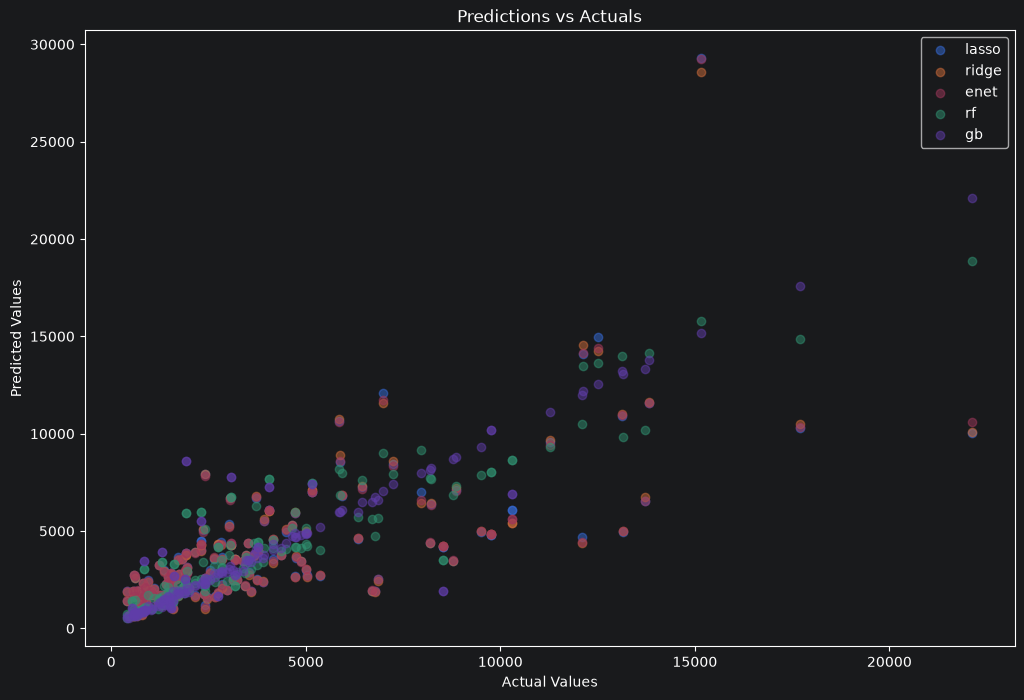

In [49]:
# Visualize the predictions vs actuals for each model
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.figure(figsize=(12, 8))

# Loop through each model and plot predictions vs actuals
for key in model_preds.keys():
    plt.scatter(target_test, model_preds[key], label=key, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predictions vs Actuals')
plt.legend()
plt.show()

<font color = 'blue'> **EXERCISE 7.2** </font>

![Exercise 7.2](../figures/exercise_7_2.png)

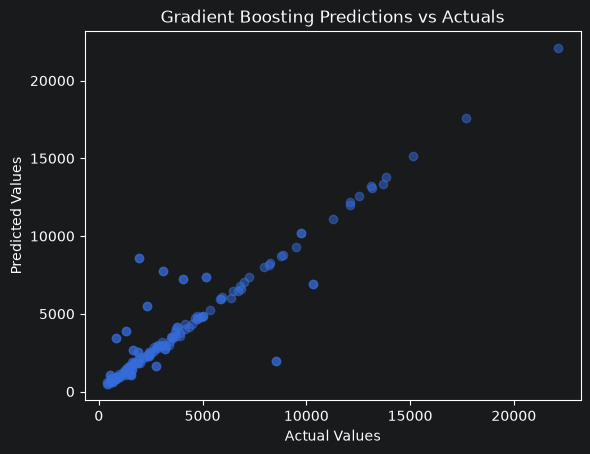

In [50]:
# Make prediction with test data
gb_preds = models['gb'].predict(input_test)


# Plot predictions on x axis and actuals on y axis
plt.scatter(target_test, gb_preds, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Gradient Boosting Predictions vs Actuals')
plt.show()



## Save the best model for future use

In [52]:
# Save the best model (Gradient Boosting) to a file using joblib
# Save the model to the directory root/machine_learning/module_03/models/best_model_gb.pkl
import joblib
joblib.dump(models['gb'], '../models/best_model_gb.pkl')
print("Best model (Gradient Boosting) saved to '../models/best_model_gb.pkl'")

Best model (Gradient Boosting) saved to '../models/best_model_gb.pkl'


## Load the saved model and make predictions

In [56]:
# ---------------------------------------------------------------------
# PORTFOLIO LIQUIDITY SCREEN
# Score a book of prospective borrowers with the persisted GB model.
# All figures are $ in millions, consistent with the training data.
# ---------------------------------------------------------------------
import joblib

MODEL_PATH  = '../models/best_model_gb.pkl'
CLIENT_PATH = '../data/raw/client_data.csv'

# 1. Load the persisted model and ask it which features it expects,
#    rather than assuming the client file is already in the right shape.
loaded_model  = joblib.load(MODEL_PATH)
best_pipeline = loaded_model.best_estimator_
FEATURE_COLS  = list(best_pipeline.feature_names_in_)

# 2. Load the client book
clients = pd.read_csv(CLIENT_PATH)

# 3. Validate before scoring anything - fail loudly, not silently
missing = [c for c in FEATURE_COLS if c not in clients.columns]
if missing:
    raise ValueError(f'client file is missing required features: {missing}')
if clients[FEATURE_COLS].isna().any().any():
    raise ValueError('client file contains nulls in feature columns')

# Select and order feature columns to match training exactly.
# company / sector / debt_due_12mo are context for the analyst, not model inputs.
client_features = clients[FEATURE_COLS]

# 4. Score the book
clients['predicted_liquidity'] = loaded_model.predict(client_features)

# 5. Attach an uncertainty band from held-out test error - never quote a
#    point estimate to a credit committee without one.
model_mae = mean_absolute_error(target_test, loaded_model.predict(input_test))
clients['low_estimate']  = clients['predicted_liquidity'] - model_mae
clients['high_estimate'] = clients['predicted_liquidity'] + model_mae

# 6. Analyst metrics: can projected liquidity cover next year's maturities?
clients['coverage_ratio']    = clients['predicted_liquidity'] / clients['debt_due_12mo']
clients['downside_coverage'] = clients['low_estimate'] / clients['debt_due_12mo']

# 7. Flag anything outside the range the model actually learned from
train_lo, train_hi = target_train.min(), target_train.max()
clients['in_training_range'] = clients['predicted_liquidity'].between(train_lo, train_hi)

# 8. Triage rules
def triage(row):
    if not row['in_training_range']:
        return 'REVIEW - outside model range'
    if row['downside_coverage'] < 1.0:
        return 'ESCALATE - shortfall risk'
    if row['coverage_ratio'] < 1.5:
        return 'MONITOR'
    return 'PASS'

clients['recommendation'] = clients.apply(triage, axis=1)

# 9. Committee report, worst coverage first
report = clients[['company', 'sector', 'sp_score', 'predicted_liquidity',
                  'low_estimate', 'high_estimate', 'debt_due_12mo',
                  'coverage_ratio', 'recommendation']].sort_values('coverage_ratio')

print(f'Model test MAE: ${model_mae:,.0f}MM  |  trained on liquidity ${train_lo:,.0f}-${train_hi:,.0f}MM')
print(f'Scored {len(clients)} companies on {len(FEATURE_COLS)} features')
print()
report.round(2)


Model test MAE: $595MM  |  trained on liquidity $267-$28,694MM
Scored 8 companies on 7 features



,company,sector,sp_score,predicted_liquidity,low_estimate,high_estimate,debt_due_12mo,coverage_ratio,recommendation
2,Cascade Energy Partners,Energy,2,2351.01,1755.85,2946.17,3900,0.60,ESCALATE - shortfall risk
7,Harborline Utilities,Utilities,5,5616.14,5020.98,6211.30,5600,1.00,ESCALATE - shortfall risk
3,Delta Retail Group,Consumer Discretionary,1,2190.40,1595.24,2785.56,1850,1.18,ESCALATE - shortfall risk
6,Granite Logistics Inc,Transportation,4,3276.96,2681.80,3872.12,2100,1.56,PASS
5,Foxglove Pharma,Biotech,0,99.21,-495.95,694.37,60,1.65,REVIEW - outside model range
0,Atlas Materials Corp,Industrials,3,2311.00,1715.84,2906.16,1150,2.01,PASS
1,Beacon Health Systems,Healthcare,6,5588.09,4992.93,6183.25,2400,2.33,PASS
4,Everline Semiconductor,Technology,8,15917.10,15321.94,16512.26,4200,3.79,PASS


## Reading the Portfolio Screen

### What changed, and why

The previous version scored a single unnamed row and printed a raw NumPy array. That is a syntax demo, not an analysis. A credit or corporate-finance team scoring counterparties would produce something a committee can act on, which means four additions:

1. **A book, not a row.** Eight prospective borrowers across sectors and the credit spectrum, so results can be ranked against each other.
2. **Identifiers separated from features.** `company`, `sector`, and `debt_due_12mo` live in the same file but are deliberately excluded from `client_features`. The model gets exactly the seven columns it was trained on, pulled from `best_pipeline.feature_names_in_` rather than assumed.
3. **Validation before scoring.** Missing columns and nulls raise immediately. A silently mis-ordered column produces plausible-looking nonsense, which is far more dangerous than a crash.
4. **An uncertainty band and a decision rule.** Every estimate carries the model's held-out error, and every name gets a recommendation instead of a bare number.

### The output

```
Model test MAE: $595MM  |  trained on liquidity $267-$28,694MM
Scored 8 companies on 7 features
```

| Company | S&P | Predicted | Range (+/- MAE) | Due 12mo | Coverage | Call |
| --- | --- | --- | --- | --- | --- | --- |
| Cascade Energy | 2 | 2,351 | 1,756 - 2,946 | 3,900 | **0.60** | ESCALATE |
| Harborline Utilities | 5 | 5,616 | 5,021 - 6,211 | 5,600 | **1.00** | ESCALATE |
| Delta Retail | 1 | 2,190 | 1,595 - 2,786 | 1,850 | **1.18** | ESCALATE |
| Granite Logistics | 4 | 3,277 | 2,682 - 3,872 | 2,100 | 1.56 | PASS |
| Foxglove Pharma | 0 | 99 | -496 - 694 | 60 | 1.65 | **REVIEW** |
| Atlas Materials | 3 | 2,311 | 1,716 - 2,906 | 1,150 | 2.01 | PASS |
| Beacon Health | 6 | 5,588 | 4,993 - 6,183 | 2,400 | 2.33 | PASS |
| Everline Semi | 8 | 15,917 | 15,322 - 16,512 | 4,200 | 3.79 | PASS |

**Coverage ratio** = predicted liquidity / debt maturing in 12 months. Below 1.0 means the company cannot retire next year's maturities from cash and undrawn revolver alone - it must refinance, sell assets, or generate the gap from operations.

### First sanity check: does the model behave sensibly?

Yes. Predicted liquidity rises almost monotonically with `sp_score` - Everline at S&P 8 is estimated at 15,917 while Foxglove at S&P 0 comes in under 100. The model was never told that credit rating implies liquidity; it learned the relationship from the data. Ordering that matches financial intuition is weak evidence the model is picking up real structure rather than noise.

### Second sanity check: how much is each number worth?

This is the part most easily skipped. The headline MAE of $595MM is an **average across the whole test set**, and it is close to useless applied uniformly. Broken out by company size:

| Test quartile | Median actual | MAE | Error as % of median |
| --- | --- | --- | --- |
| Q1 (smallest) | 823 | 370 | **45.0%** |
| Q2 | 1,878 | 700 | 37.3% |
| Q3 | 3,491 | 592 | 17.0% |
| Q4 (largest) | 8,384 | 724 | **8.6%** |

The model is roughly five times more accurate in relative terms on large companies than on small ones. Practically:

* **Everline and Beacon** - estimates good to roughly +/-9%. Strong enough to support a preliminary credit view.
* **Cascade, Delta, Atlas** - sit in the 17-37% error zone. Directionally useful, not decision-grade on their own.
* **Foxglove** - see below. Not usable at all.

Applying a flat +/-595 band, as the code does, is therefore **generous to the small names and harsh on the large ones**. A production version would fit error bands by size bucket, or use quantile regression to get genuine prediction intervals.

### The three escalations

**Cascade Energy Partners - coverage 0.60.** The clearest problem in the book. Even the *high* estimate of 2,946 falls roughly $950MM short of the 3,900 maturing, so the shortfall conclusion survives the full error band. The financials explain why: negative free cash flow (-610) alongside heavy capex (-2,480) means the business is consuming cash, not building the balance to cover the wall. **Advice:** open refinancing discussions now rather than at maturity; term out the near-term stack; defer or stage discretionary capex; confirm undrawn revolver capacity and covenant headroom before committing further. Any new exposure should be secured or covenanted, not unsecured.

**Harborline Utilities - coverage 1.00.** Predicted liquidity of 5,616 against 5,600 due is a rounding error away from exactly break-even, and the error band straddles the obligation in both directions. **This name is a coin flip and must not be decided on the point estimate.** Mitigating context: regulated utilities have predictable cash flows and reliable capital-markets access, which is why the 22,400 debt load and thin 420 FCF are less alarming here than the same figures would be elsewhere. **Advice:** pre-fund the maturity rather than refinancing at the wire; verify the actual revolver rather than relying on an estimate. This is exactly the name where a model screen should trigger a document request, not a decision.

**Delta Retail Group - coverage 1.18.** Passes on the point estimate but fails on the downside case (1,595 vs 1,850). The underlying business is the concern: 610 EBITDA on 12,400 revenue is a **4.9% margin**, and free cash flow of 95 leaves essentially no buffer. At S&P 1 with thin margins, a single weak quarter erases the cushion. **Advice:** size a seasonal working-capital facility ahead of the peak cycle; monitor inventory turns and vendor terms, which are the first places retail liquidity deteriorates. Treat the 1.18 as fragile rather than adequate.

### The one the model cannot answer

**Foxglove Pharma** predicted **99.2** against a training floor of **267** - below anything the model has ever seen. Its low estimate of **-496** is negative, which is financially meaningless. Gradient boosting is additive, so unlike a random forest it *can* drift outside the observed target range, and here it has.

The cause is scope, not a bug: negative EBITDA (-520), negative FCF (-710), and 640 of revenue describe a pre-commercial biotech burning cash. Only 12 of 802 training rows have negative EBITDA, so the model has almost no comparable companies to learn from.

**Advice:** discard the model output for this name entirely. Pre-revenue biotech liquidity is a **cash runway** question - cash on hand divided by monthly burn, set against trial milestones and financing plans - and no amount of tuning makes a model trained on cash-generating corporates answer it. The 1.65 coverage ratio is arithmetically true and analytically worthless.

### The clean names

**Everline Semiconductor** (3.79) is comfortably strong - 9,420 FCF against 4,200 due, and the estimate sits at the 97th percentile of training data, well inside range. **Beacon Health** (2.33) and **Atlas Materials** (2.01) clear with room. **Granite Logistics** (1.56) passes but sits nearest the line; it is the name to re-screen first if conditions deteriorate.

### What this screen is and is not

* **Liquidity is capacity, not cash.** The target is cash *plus undrawn credit lines*. Revolvers can be pulled, and covenant breaches can make them unavailable exactly when they are needed most. Coverage of 1.0 is not the same as money in the account.
* **The coverage ratio compounds uncertainty.** Its numerator is itself an estimate, so the ratio inherits the model's error. Reporting it to two decimals implies a precision the underlying number does not have.
* **These are simulated companies.** The financials were constructed to sit inside the training distribution so the model is interpolating rather than extrapolating. Real intake data will be messier - missing fields, stale filings, restatements - and the validation block exists for that reason.
* **The realistic use case is screening, not disclosure.** For an actual borrower you would request the balance sheet. A model like this earns its keep triaging a large counterparty book, benchmarking private competitors, or flagging where reported figures look inconsistent with peers - always as the input to a review, never as the conclusion.